В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням kNearestNeighboors, знайдемо оптимальні гіперпараметри для цього методу і зробимо базові ансамблі. Це дасть змогу порівняти перформанс моделі з попередніми вивченими методами.

0. Зчитайте дані `train.csv` та зробіть препроцесинг використовуючи написаний Вами скрипт `process_bank_churn.py` так, аби в результаті отримати дані в розбитті X_train, train_targets, X_val, val_targets для експериментів.

  Якщо Вам не вдалось реалізувати в завданні `2.3. Дерева прийняття рішень` скрипт `process_bank_churn.py` - можна скористатись готовим скриптом з запропонованого рішення того завдання.

In [42]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import process_bank_churn as pbc
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [44]:
# Read train set from a file
raw_df = pd.read_csv('train.csv')
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [45]:
# Preprocess data
data = pbc.preprocess_data(raw_df)
print(data.input_cols)

['Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


1. Навчіть на цих даних класифікатор kNN з параметрами за замовченням і виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах. Зробіть заключення про отриману модель: вона хороша/погана, чи є high bias/high variance?

In [46]:
# Fit kNN model
model = KNeighborsClassifier()
model.fit(data.X_train, data.y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [47]:
# Create function to predict probabilities and calculate AUROC
def predict_and_show_metrics(model, inputs, target):
    probs = model.predict_proba(inputs)

    fpr, tpr, thresholds = roc_curve(target, probs[:, 1])
    auc_roc = auc(fpr, tpr)

    return auc_roc

In [48]:
# Function to get AUROC for Train and Val
def get_auroc_for_test_and_val(model, data):
    auc_roc_train = predict_and_show_metrics(model, data.X_train, data.y_train)
    auc_roc_val = predict_and_show_metrics(model, data.X_val, data.y_val)

    return {
        'Train AUROC': auc_roc_train,
        'Val AUROC': auc_roc_val
    }

In [49]:
# Show AUROC for Test and Val
print(get_auroc_for_test_and_val(model, data))

{'Train AUROC': 0.944687839697256, 'Val AUROC': 0.8174566156800878}


**Висновок.** Показник `AUROC` суттєво відрізняється для Трейн і Валідейшн наборів. Це говорить про наявність high bias-у.

2. Використовуючи `GridSearchCV` знайдіть оптимальне значення параметра `n_neighbors` для класифікатора `kNN`. Псотавте крос валідацію на 5 фолдів.

  Після успішного завершення пошуку оптимального гіперпараметра
    - виведіть найкраще значення параметра
    - збережіть в окрему змінну `knn_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `knn_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пукнтом (2) цього завдання? Чи є вона краще за дерево прийняття рішень з попереднього ДЗ?

In [50]:
# Search for the best params for kNN with GridSearchCV
selector = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={'n_neighbors': range(2, 101)},
    scoring='roc_auc',
    cv=5
)

selector.fit(data.X_train, data.y_train)
selector.best_params_

{'n_neighbors': 27}

In [51]:
# Get best estimator and show AUROC for it
knn_best = selector.best_estimator_
print(get_auroc_for_test_and_val(knn_best, data))

{'Train AUROC': 0.8960481411046383, 'Val AUROC': 0.8599663900130324}


**Висновок.** Дана модель показує кращі результати на Валідейшні, ніж попередня. Також показники на Трейні та Валідейшні тепер ближчі, що свідчить про зниження bias-у. Але ця модель все ж таки показує результати гірші, ніж Дерево Прийняття Рішень з попереднього ДЗ (AUROC > 0.9 на Валідейшні).

3. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `GridSearchCV` за сіткою параметрів
  - `max_depth` від 1 до 20 з кроком 2
  - `max_leaf_nodes` від 2 до 10 з кроком 1

  Обовʼязково при цьому ініціюйте модель з фіксацією `random_state`.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_best` найкращу модель, знайдену з `GridSearchCV`
    - оцініть якість передбачень  `dt_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли вручну?

In [54]:
%%time

# Search for the best params for Decision Tree with GridSearchCV
param_grid = {
    'max_depth': np.arange(1, 21, 2),
    'max_leaf_nodes': np.arange(2, 11, 1)
}

tree_selector = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=13),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3
)

tree_selector.fit(data.X_train, data.y_train)
tree_selector.best_params_

CPU times: user 2.69 s, sys: 149 ms, total: 2.84 s
Wall time: 2.85 s


{'max_depth': np.int64(5), 'max_leaf_nodes': np.int64(10)}

In [55]:
# Show AUROC
dt_best = tree_selector.best_estimator_
print(get_auroc_for_test_and_val(dt_best, data))

{'Train AUROC': 0.900998049067729, 'Val AUROC': 0.886456204129227}


**Висновок.** Ця модель ще краща ніж попередня. І можливе перетренування доволі низьке. Але вона все ще гірша, ніж у ДЗ по деревам. Тут варто було б розширити діапазон пошуку для параметрів, а також додати значення None. Тут пошук тривав менше 3 секунд, тому можна легко його розширити.

4. Виконайте пошук оптимальних гіперпараметрів для `DecisionTreeClassifier` з `RandomizedSearchCV` за заданою сіткою параметрів і кількість ітерацій 40.

  Поставте кросвалідацію на 3 фолди, `scoring='roc_auc'`, зафіксуйте `random_seed` процедури крос валідації та виміряйте, скільки часу потребує пошук оптимальних гіперпараметрів.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення параметра
    - збережіть в окрему змінну `dt_random_search_best` найкращу модель, знайдену з `RandomizedSearchCV`
    - оцініть якість передбачень  `dt_random_search_best` на тренувальній і валідаційній вибірці з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи ця модель краща за ту, що ви знайшли з `GridSearch`?
    - проаналізуйте параметри `dt_random_search_best` і порівняйте з параметрами `dt_best` - яку бачите відмінність? Ця вправа потрібна аби зрозуміти, як різні налаштування `DecisionTreeClassifier` впливають на якість моделі.

In [56]:
params_dt = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': np.arange(1, 20),
    'max_leaf_nodes': np.arange(2, 20),
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [None, 'sqrt', 'log2']
}

In [57]:
%%time

# Search for the best params for Decision Tree with RandomizedSearchCV
dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=13),
    param_distributions=params_dt,
    scoring='roc_auc',
    cv=3,
    n_iter=40,
    random_state=42
)

dt_random.fit(data.X_train, data.y_train)
dt_random.best_params_

CPU times: user 622 ms, sys: 84.9 ms, total: 707 ms
Wall time: 708 ms


{'splitter': 'best',
 'min_samples_split': 20,
 'min_samples_leaf': 2,
 'max_leaf_nodes': np.int64(14),
 'max_features': None,
 'max_depth': np.int64(16),
 'criterion': 'entropy'}

In [58]:
# Show AUROC
dt_random_search_best = dt_random.best_estimator_
print(get_auroc_for_test_and_val(dt_random_search_best, data))

{'Train AUROC': 0.9171815198180546, 'Val AUROC': 0.9107503944029083}


**Висновок.** Ця модель показує дуже хороші результати - причому на обох сетах: Трейн і Валідейшн. Вона найкраща у цій ДЗ. І пошук параметрів при цьому тривав менше 1 секунди.

Порівнюючи `dt_random_search_best` i `dt_best`,
- `dt_best` має параметри:
    - {'max_depth': 5, 'max_leaf_nodes': 10},
- а `dt_random_search_best`:
    - {'splitter': 'best',
 'min_samples_split': 20,
 'min_samples_leaf': 2,
 'max_leaf_nodes': 14,
 'max_features': None,
 'max_depth': 16,
 'criterion': 'entropy'}

Значення `max_depth` і `max_leaf_nodes` доволі сильно відрізняються для цих двох моделей. Це відбувається за рахунок того, що модель з рандомізованим пошуком має більше параметрів і деякі з них виявились важливими і впливають як на інші параметри, так і на кінцевий результат.

5. Якщо у Вас вийшла метрика `AUROC` в цій серії експериментів - зробіть ще один `submission` на Kaggle і додайте код для цього і скріншот скора на публічному лідерборді нижче.

  Сподіваюсь на цьому етапі ви вже відчули себе справжнім дослідником 😉

In [59]:
# Read test data
test_raw_df = pd.read_csv('test.csv')
test_raw_df.columns

Index(['id', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [60]:
# Preprocess test data
X_test = pbc.preprocess_new_data(test_raw_df, data)

# Calculate probabilities for test and put them into the dataframe
test_raw_df['Exited'] = dt_random_search_best.predict_proba(X_test)[:, 1]

# Read submission file
submission = pd.read_csv('sample_submission.csv')

# Copy results to submission data frame
submission['Exited'] = submission['id'].map(test_raw_df.set_index('id')['Exited'])
print(submission.head())

# Check for missed values
print(submission.info())

# Write submission into a file
submission.to_csv('submission_random_search_hw.csv', index=False)

      id    Exited
0  15000  0.246602
1  15001  0.011333
2  15002  0.113565
3  15003  0.557123
4  15004  0.113565
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      10000 non-null  int64  
 1   Exited  10000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 156.4 KB
None


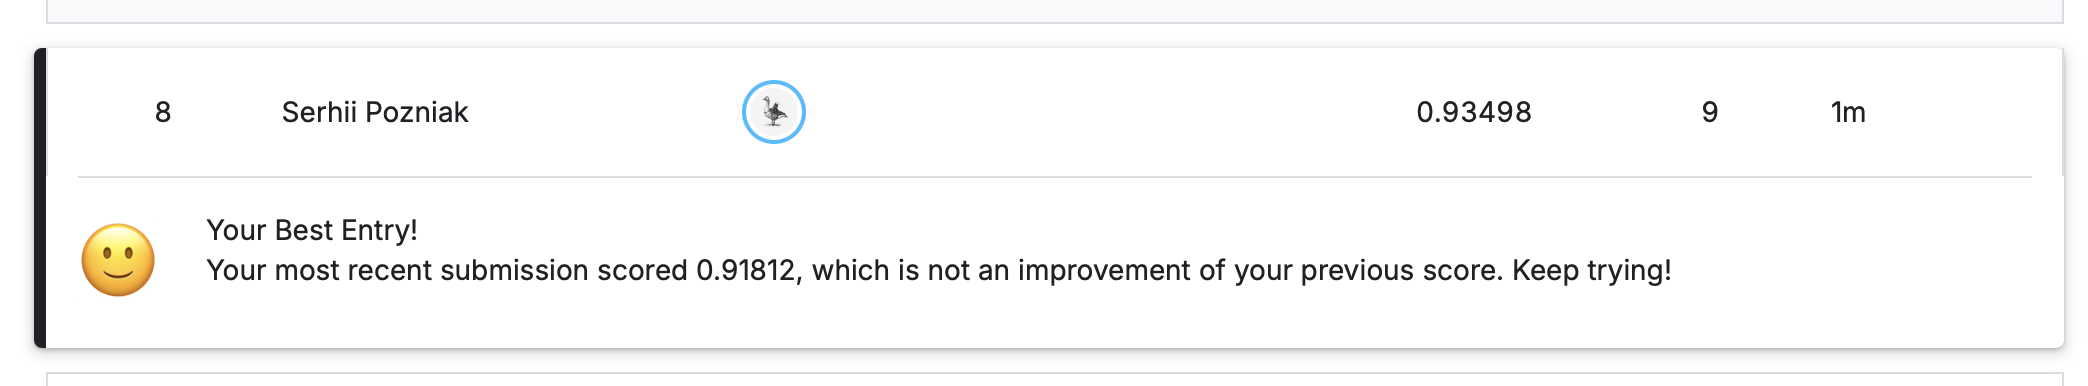